In [3]:
import wilyapi

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt


FIRST_REVISION = "659d0d3   "

In [70]:
api = wilyapi.WilyAPI()

file_paths = [
    *api.list_files(subdir="feets"),
    "feets/extractors/core.py",
    "feets/extractors/register.py",
]

df_raw = pd.DataFrame()
for file_path in file_paths:
    df = api.file_report(
        file_path=file_path,
        metrics=["mi"],
        add_filename=True,
        add_revision_author=False,
    ).reset_index(drop=False)
    df_raw = pd.concat([df_raw, df], ignore_index=True)

In [152]:
min_date = df_raw[df_raw["Revision"] == FIRST_REVISION]["Date"].values[0]
df = df_raw[df_raw["Date"] >= min_date]
df = df.replace(
    {
        "feets/extractors/core.py": "feets/extractors/extractor.py",
        "feets/extractors/register.py": "feets/extractors/registry.py",
    }
)
df = df.dropna()

/tmp/ipykernel_18416/908375014.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


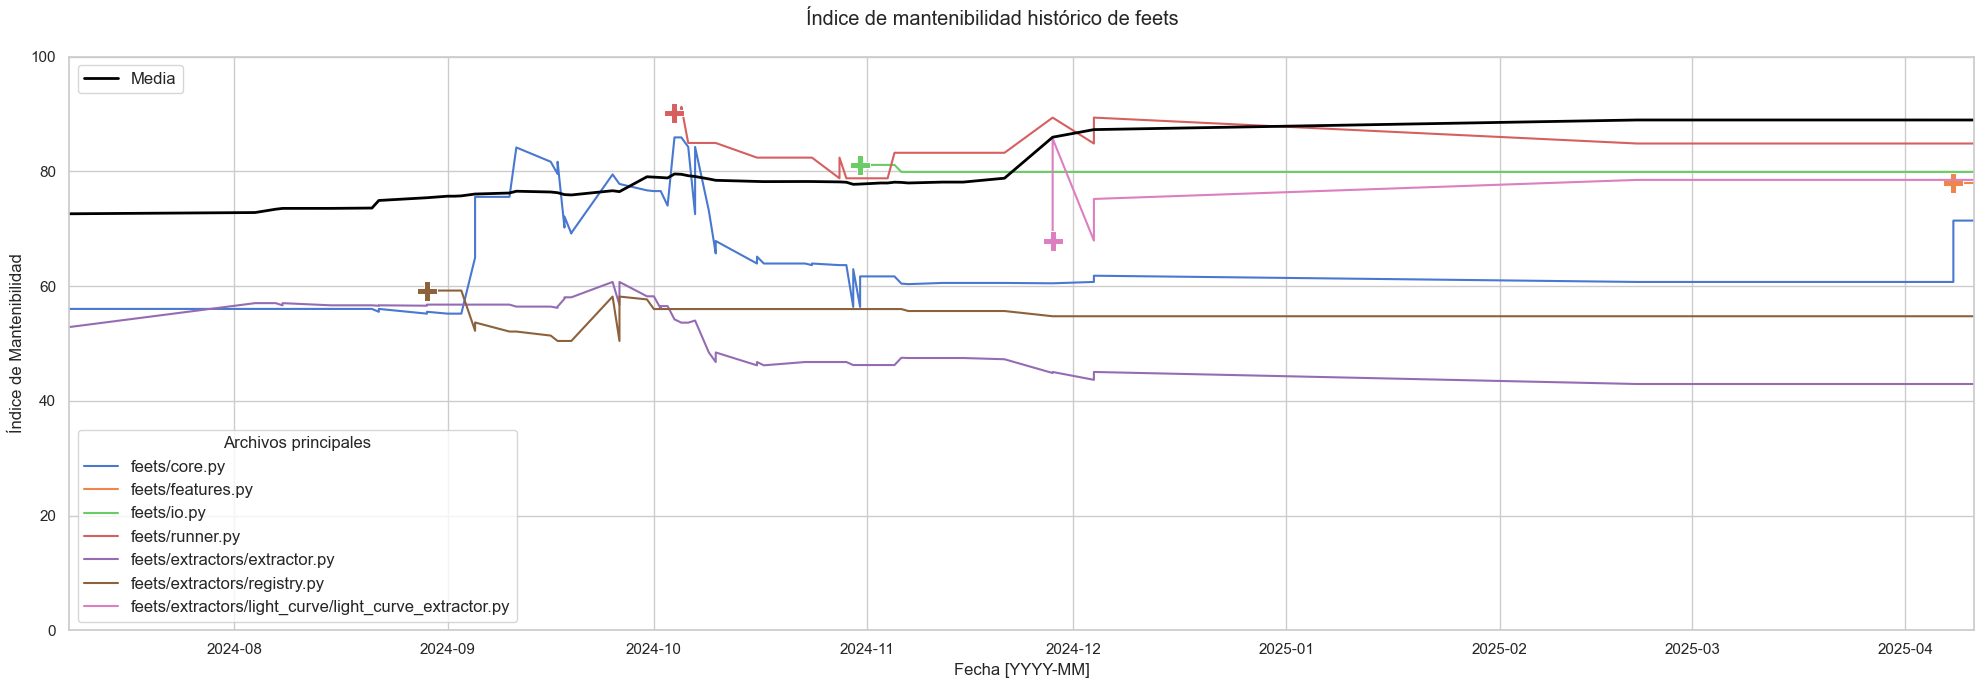

In [ ]:
sns.set(style="whitegrid", palette="muted")

core_files = [
    "feets/core.py",
    "feets/features.py",
    "feets/io.py",
    "feets/runner.py",
    "feets/extractors/extractor.py",
    "feets/extractors/registry.py",
    "feets/extractors/light_curve/light_curve_extractor.py",
]
df_core = df[df["File"].isin(core_files)]
df_mean = df.groupby("Date")["Maintainability Index"].mean().reset_index()

fig, ax = plt.subplots(1, 1, figsize=(20, 7))


g = sns.lineplot(
    ax=ax,
    x="Date",
    y="Maintainability Index",
    hue="File",
    hue_order=core_files,
    data=df_core,
    estimator=None,
    style=df["File"].isin(df[df["Revision"] == FIRST_REVISION]["File"]),
    dashes=False,
    markers={True: ",", False: "P"},
    markersize=15,
    markevery=[0],
)

g = sns.lineplot(
    ax=ax,
    x="Date",
    y="Maintainability Index",
    data=df_mean,
    estimator=None,
    color="black",
    label="Media",
    linewidth=2,
)

fig.suptitle("Índice de mantenibilidad histórico de feets")

ax.set_ylabel("Índice de Mantenibilidad")
ax.set_xlabel("Fecha [YYYY-MM]")
ax.set_ylim(0, 100)
ax.set_xlim(df["Date"].min(), df["Date"].max())

h, l = ax.get_legend_handles_labels()
l1 = ax.legend(h[:-3], l[:-3], loc="lower left", fontsize=12, title="Archivos principales")
l2 = ax.legend(h[-1:], l[-1:], loc="upper left", fontsize=12)
ax.add_artist(l1)

fig.tight_layout()
fig.show()
fig.savefig("MI_feets.pdf", dpi=300)